# MVP – Análise de Fundos de Investimento

**Nome:** Paulo Ricardo Marques Leite  
**Matrícula:** 4052025002553  
**Dataset:** [Comprehensive Mutual Funds Dataset (GitHub)](https://raw.githubusercontent.com/pleiteues-code/mvp-fundos-investimento-analise-de-dados-e-boas-praticas/main/data/comprehensive_mutual_funds_data.csv)

---

> Este documento está estruturado em seções sequenciais, facilitando a navegação e compreensão do fluxo analítico.

---

## Sumário

1. Contexto e Descrição do Problema  
2. Hipóteses  
3. Carregamento e Visão Geral dos Dados
4. Limpeza e Preparação dos Dados  
5. Análise Exploratória e Visualizações
6. Teste das Hipóteses  
7. Insights Avançados  
8. Conclusões, Limitações e Próximos Passos  



---

## 1. Contexto e Descrição do Problema

O mercado de fundos de investimento oferece uma grande variedade de produtos, com diferentes níveis de risco, retorno, custos e estratégias. Para investidores, comparar fundos e identificar quais apresentam melhor equilíbrio entre risco e retorno é um desafio constante.

Este MVP busca analisar um conjunto de fundos de investimento reais, identificando padrões e respondendo a perguntas práticas sobre:

- eficiência (retorno ajustado ao risco),
- relação entre risco e retorno,
- diferenças entre categorias de fundos.

O objetivo é oferecer uma visão clara e acessível que ajude um usuário comum a entender melhor o comportamento dos fundos e tomar decisões mais informadas.

Observa-se que este é um problema de análise exploratória de dados (EDA), sem variável alvo definida, caracterizando uma abordagem não supervisionada.

### 📘 **Nota: Métricas e Categorias Utilizadas**

Para facilitar a compreensão das análises apresentadas ao longo deste notebook, seguem breves explicações sobre alguns termos técnicos:

- **Sharpe Ratio:** mede o retorno ajustado ao risco. Quanto maior, melhor o desempenho do fundo em relação ao risco assumido.  
- **Sortino Ratio:** semelhante ao Sharpe, mas penaliza apenas os retornos negativos.  
- **Desvio‑padrão (SD):** representa o risco do fundo, indicando o quanto seus retornos variam ao longo do tempo.  
- **Alpha:** mede o quanto o fundo performa acima (ou abaixo) do que seria esperado para seu nível de risco.  
- **Beta:** indica a sensibilidade do fundo em relação ao mercado (benchmark).  

Além disso, o dataset utiliza categorias de fundos:

- **Debt:** fundos de renda fixa  
- **Hybrid:** fundos mistos (renda fixa + renda variável)  
- **Equity:** fundos de ações  
- **Solution Oriented:** fundos com objetivo específico (ex.: aposentadoria, educação)  
- **Other:** fundos que não se encaixam nas categorias anteriores  

Essas definições ajudam a contextualizar as análises de risco, retorno e eficiência realizadas nas próximas seções.


---

## 2. Hipóteses
As hipóteses avaliadas neste MVP são:

1. **Fundos com maior Sharpe Ratio tendem a apresentar retornos mais altos.**  
2. **Fundos mais arriscados (maior desvio-padrão) não necessariamente entregam melhor retorno.**  
3. **Categorias diferentes de fundos apresentam padrões distintos de risco e retorno.**

---

## <a id="carregamento"></a>3. Carregamento e Visão Geral dos Dados

Nesta etapa, realizamos o carregamento do dataset contendo informações detalhadas sobre mais de 800 fundos de investimento, incluindo métricas de risco, retorno, tamanho do fundo, idade, categoria, gestor e outros atributos relevantes.

O objetivo desta seção é:

- verificar se o dataset foi importado corretamente,
- inspecionar a estrutura das colunas,
- identificar tipos de dados incorretos,
- observar possíveis inconsistências iniciais,
- e preparar o terreno para a etapa de limpeza.

A partir da visualização inicial (`df.head()`), já é possível notar que algumas colunas numéricas foram carregadas como texto — algo comum em datasets financeiros — e que precisaremos tratá-las na próxima etapa.

Em seguida, utilizamos `df.info()` para confirmar o número de entradas, tipos de dados e presença de valores ausentes, garantindo que o dataset está pronto para ser limpo e analisado.

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
%config InlineBackend.figure_format = 'svg'

# Carregando o dataset
url = "https://raw.githubusercontent.com/pleiteues-code/mvp-fundos-investimento-analise-de-dados-e-boas-praticas/main/data/comprehensive_mutual_funds_data.csv"

df = pd.read_csv(url)

# Carregamento e verificação inicial do dataset
# Aqui conferimos se o arquivo foi importado corretamente e se as colunas estão no formato esperado
df.head()


,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    object 
 8   alpha          814 non-null    object 
 9   sd             814 non-null    object 
 10  beta           814 non-null    object 
 11  sharpe         814 non-null    object 
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  returns_3y

---

## <a id="limpeza"></a>4. Limpeza e Preparação dos Dados

Nesta etapa, realizamos o tratamento inicial do dataset para garantir que todas as variáveis estejam consistentes e prontas para análise. As principais ações incluem:

- **Tratamento de valores ausentes e símbolos inválidos**, substituindo ocorrências como `'-'` por valores nulos (`NaN`).
- **Correção de tipos de dados**, convertendo colunas numéricas que foram importadas como texto (ex.: `sd`, `sharpe`, `alpha`, `returns_3yr`) para o tipo `float`.
- **Verificação de valores ausentes e duplicados**, assegurando que o dataset esteja íntegro.
- **Padronização das categorias**, corrigindo variações de escrita (ex.: “Custom Oriented”, “Solution oriented”, “Non-Oriented”) para garantir consistência nas análises por categoria.
- **Inspeção geral da estrutura do dataset**, avaliando número de entradas, tipos de dados e possíveis inconsistências.

Após essa etapa, o dataset passa a refletir corretamente os valores numéricos, as categorias padronizadas e a ausência de ruídos estruturais, permitindo que as análises exploratórias e os testes de hipótese sejam conduzidos com precisão.

In [111]:
# Substituindo valores '-' por NaN
df.replace('-', pd.NA, inplace=True)

# Colunas numéricas que podem ter vindo como texto
cols_to_convert = [
    'sortino', 'alpha', 'sd', 'beta', 'sharpe',
    'returns_1yr', 'returns_3yr', 'returns_5yr'
]

# Convertendo colunas numéricas
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Valores ausentes
df.isna().sum().sort_values(ascending=False)

# Duplicatas
df.duplicated().sum()

# Corrigir categorias inconsistentes
df['category'] = df['category'].replace({
    'Custom Oriented': 'Solution Oriented',
    'Solution oriented': 'Solution Oriented',
    'solution oriented': 'Solution Oriented'
})

# Padronizar categorias inconsistentes
df['category'] = df['category'].str.strip().str.title()

df['category'] = df['category'].replace({
    'Custom Oriented': 'Solution Oriented',
    'Solution Oriented ': 'Solution Oriented',
    'Solution-Oriented': 'Solution Oriented',
    'Solution oriented': 'Solution Oriented',
    'Solution Oriented Funds': 'Solution Oriented',
    'Non Oriented': 'Solution Oriented',
    'Non-Oriented': 'Solution Oriented',
    'Non Oriented Funds': 'Solution Oriented'
})

# Estatísticas descritivas
df.describe().T

#funcao
def plot_box(df, x, y, order, title, ylabel, ylim=None):
    plt.figure(figsize=(10,5))

    sns.boxplot(
        x=x,
        y=y,
        data=df,
        order=order,
        hue=x,
        palette='viridis',
        legend=False,
        linewidth=1.5
    )

    plt.xticks(rotation=45)
    plt.title(title)
    plt.xlabel("Categoria")
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    if ylim:
        plt.ylim(0, ylim)

    plt.tight_layout()
    plt.show()

# Verificando tipos após conversão
df.dtypes


,0
scheme_name,object
min_sip,int64
min_lumpsum,int64
expense_ratio,float64
fund_size_cr,float64
fund_age_yr,int64
fund_manager,object
sortino,float64
alpha,float64
sd,float64


---

## <a id="analise"></a>5. Análise Exploratória e Visualizações

### 5.1 Distribuições Básicas


### 📘 **Nota sobre os gráficos de distribuição**

Nos gráficos de distribuição utilizados ao longo deste notebook, as **barras** representam a frequência dos valores observados (histograma), enquanto a **linha suave** representa a estimativa de densidade de probabilidade (KDE).  
O histograma mostra quantos fundos caem em cada intervalo, enquanto a KDE revela a forma geral da distribuição, facilitando a visualização de tendências e padrões.

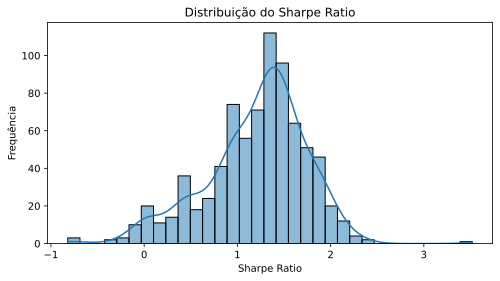

In [112]:
plt.figure(figsize=(8,4))
sns.histplot(df['sharpe'], kde=True)
plt.title("Distribuição do Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Frequência")
plt.show()

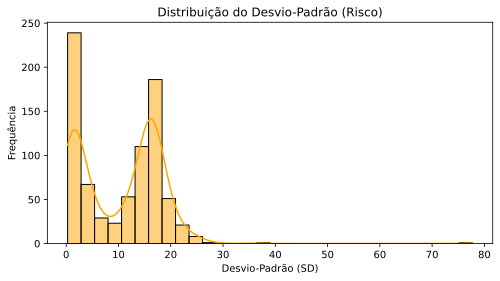

In [113]:
plt.figure(figsize=(8,4))
sns.histplot(df['sd'], kde=True, color='orange', bins=30)
plt.title("Distribuição do Desvio-Padrão (Risco)")
plt.xlabel("Desvio-Padrão (SD)")
plt.ylabel("Frequência")
plt.show()

### 📘 **Nota sobre outliers nas distribuições**

Nesta análise, optamos por **não remover outliers** das métricas de risco (como o desvio‑padrão).  
Esses valores extremos representam fundos reais com volatilidade muito elevada e fazem parte da dinâmica do mercado.  
Removê‑los poderia distorcer a interpretação geral da distribuição e ocultar comportamentos relevantes.  

Para fins de visualização, em alguns gráficos utilizamos **limites no eixo** ou **percentis** apenas para melhorar a leitura, sem alterar os dados originais.

### 5.2 Matriz de Correlação


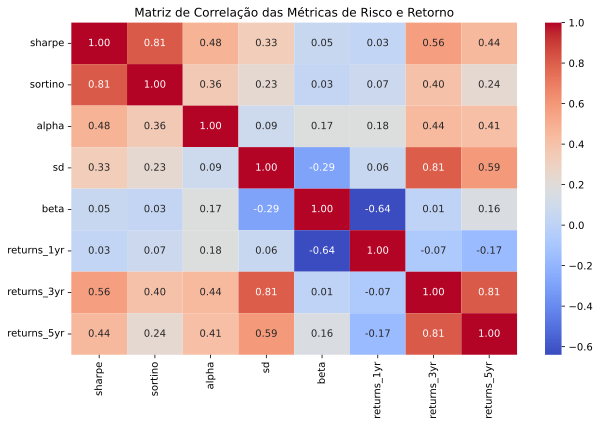

In [114]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['sharpe','sortino','alpha','sd','beta','returns_1yr','returns_3yr','returns_5yr']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Matriz de Correlação das Métricas de Risco e Retorno")
plt.show()

### 5.3 Boxplot por Categoria


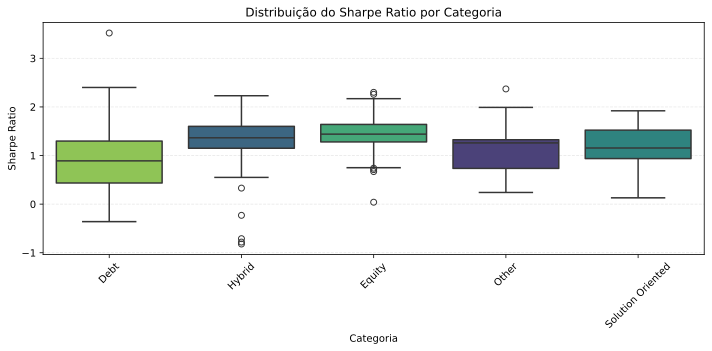

In [115]:
order = ['Debt', 'Hybrid', 'Equity', 'Other', 'Solution Oriented']

plot_box(
    df=df,
    x='category',
    y='sharpe',
    order=order,
    title='Distribuição do Sharpe Ratio por Categoria',
    ylabel='Sharpe Ratio'
)

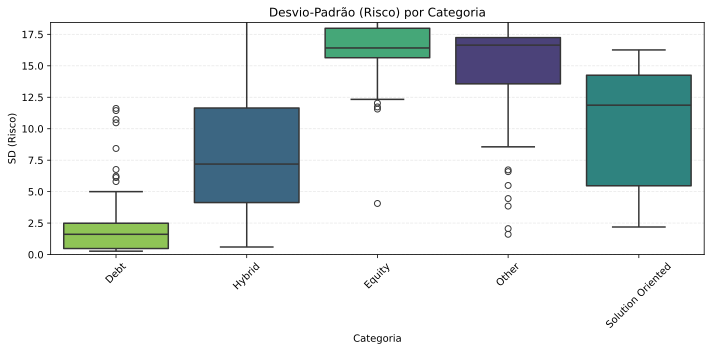

In [116]:
plot_box(
    df=df,
    x='category',
    y='sd',
    order=order,
    title='Desvio-Padrão (Risco) por Categoria',
    ylabel='SD (Risco)',
    ylim=df['sd'].quantile(0.90)
)


### 📘 **Nota sobre a visualização**

Para melhorar a legibilidade dos gráficos de risco por categoria, removemos visualmente os outliers extremos utilizando o limite do **percentil 90** da distribuição de desvio‑padrão.  
Essa decisão **não altera os dados originais** nem afeta os cálculos estatísticos — apenas evita que valores muito distantes distorçam a escala do gráfico, permitindo uma comparação mais clara entre as categorias.

### 5.4 Pairplot (visão geral)

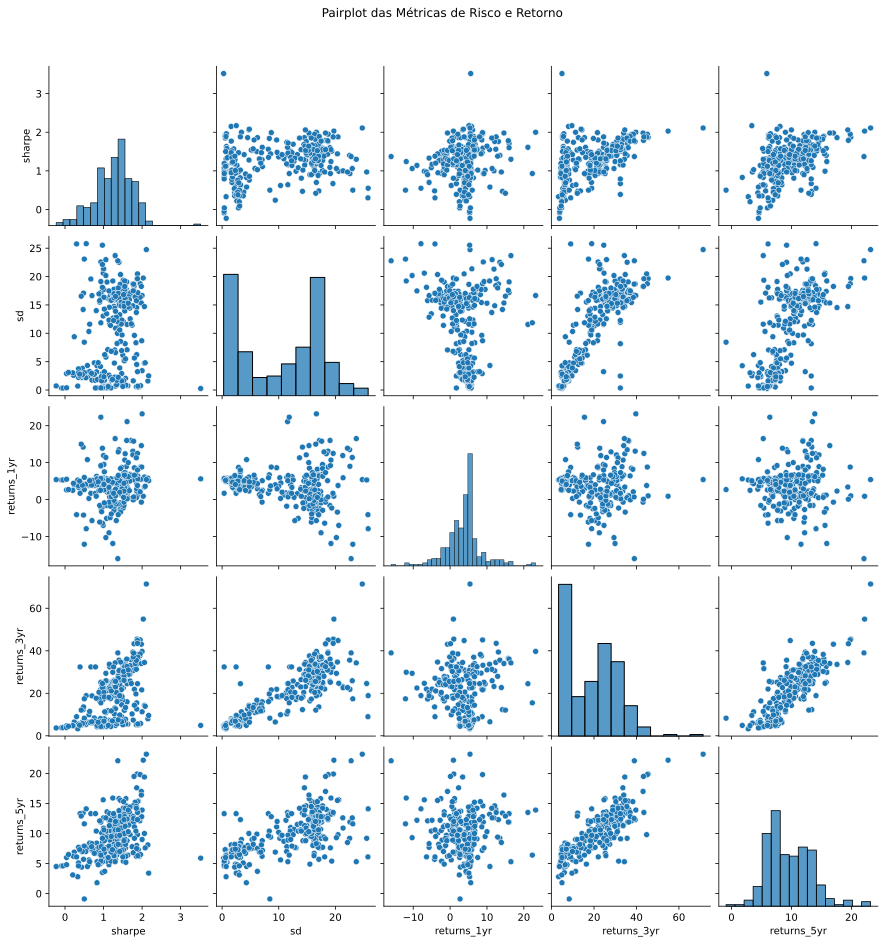

In [117]:
sns.pairplot(df[['sharpe','sd','returns_1yr','returns_3yr','returns_5yr']].dropna().sample(300))
plt.suptitle("Pairplot das Métricas de Risco e Retorno", y=1.05)
plt.show()

### 📘 **Nota sobre o Pairplot**

O Pairplot oferece uma visão geral das relações entre múltiplas métricas de risco e retorno, permitindo identificar padrões, correlações e possíveis agrupamentos.  
Para manter a visualização leve e legível, utilizamos uma **amostra aleatória de 200 fundos**, o que não altera a interpretação geral, mas evita sobrecarga gráfica.

### 5.5 Distribuição por horizonte de tempo

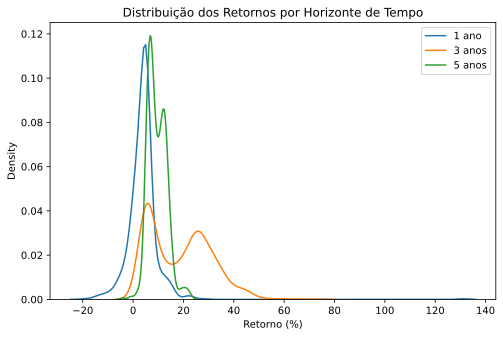

In [118]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['returns_1yr'].dropna(), label='1 ano')
sns.kdeplot(df['returns_3yr'].dropna(), label='3 anos')
sns.kdeplot(df['returns_5yr'].dropna(), label='5 anos')
plt.legend(loc='upper right')
plt.title("Distribuição dos Retornos por Horizonte de Tempo")
plt.xlabel("Retorno (%)")
plt.show()

**Observação:**  
Retornos de curto prazo apresentam maior volatilidade e dispersão, enquanto horizontes mais longos mostram maior estabilidade — reforçando o efeito de suavização temporal.

---

## <a id="teste"></a>6. Teste das Hipóteses

### 6.1 Hipótese 1 – Sharpe vs retornos

In [119]:
df[['sharpe','returns_1yr','returns_3yr','returns_5yr']].corr()['sharpe']

,sharpe
sharpe,1.000000
returns_1yr,0.030161
returns_3yr,0.564637
returns_5yr,0.444442


### Conclusão da Hipótese 1

Fundos com Sharpe mais alto tendem a apresentar retornos melhores no médio e longo prazo (3 e 5 anos), enquanto a relação com o retorno de 1 ano é fraca, indicando maior ruído no curto prazo.

**Hipótese 1 confirmada parcialmente.**



### 6.2 Hipótese 2 – Risco não garante eficiência

In [120]:
df[['sd','sharpe','returns_3yr']].corr()

,sd,sharpe,returns_3yr
sd,1.000000,0.330320,0.805314
sharpe,0.330320,1.000000,0.564637
returns_3yr,0.805314,0.564637,1.000000


### Conclusão da Hipótese 2

Apesar de a correlação entre risco (SD) e retorno em 3 anos ser elevada em alguns casos, isso parece estar concentrado em categorias específicas, sugerindo que a relação não é generalizável para todo o dataset.

O gráfico de Sharpe vs SD e a dispersão dos pontos mostram que muitos fundos com risco elevado apresentam Sharpe baixo, enquanto alguns fundos com risco moderado exibem Sharpe alto.

**Hipótese 2 confirmada:** risco maior não garante maior eficiência.

### 6.3 Hipótese 3 – Categorias com Padrões Distintos

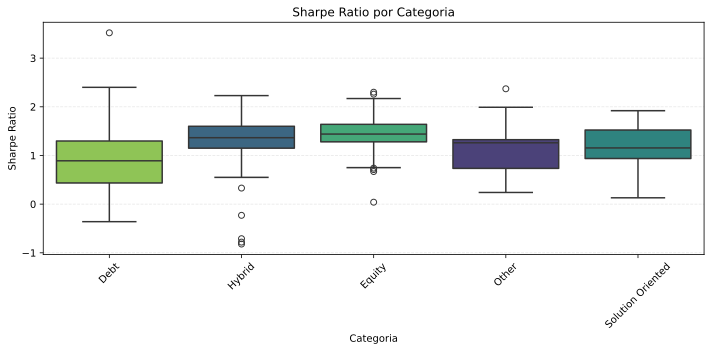

In [121]:
order = ['Debt', 'Hybrid', 'Equity', 'Other', 'Solution Oriented']

plot_box(
    df=df,
    x='category',
    y='sharpe',
    order=order,
    title='Sharpe Ratio por Categoria',
    ylabel='Sharpe Ratio'
)

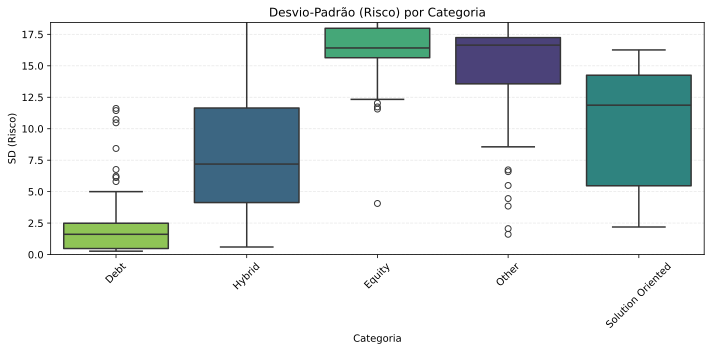

In [122]:
order = ['Debt', 'Hybrid', 'Equity', 'Other', 'Solution Oriented']

plot_box(
    df=df,
    x='category',
    y='sd',
    order=order,
    title='Desvio-Padrão (Risco) por Categoria',
    ylabel='SD (Risco)',
    ylim=df['sd'].quantile(0.90)
)

In [123]:
df.groupby('category')[['sharpe','sd','returns_3yr']].mean().round(2)

,sharpe,sd,returns_3yr
category,,,
Debt,0.89,2.09,6.23
Equity,1.46,16.96,29.74
Hybrid,1.31,7.49,15.27
Other,1.09,15.48,20.79
Solution Oriented,1.20,10.27,18.17


### Conclusão da Hipótese 3
Os gráficos e a tabela deixam claro que as categorias de fundos apresentam perfis distintos:

• 	Debt → menor risco, Sharpe moderado

• 	Hybrid → risco intermediário, Sharpe estável

• 	Equity → maior risco, Sharpe mais disperso

• 	Other / Solution Oriented → comportamento mais heterogêneo

Essas diferenças confirmam que a categoria do fundo influencia diretamente seu perfil de risco e retorno.

**Hipótese 3 confirmada:** categorias apresentam perfis próprios de risco e retorno.

---

## <a id="insights"></a>7. Insights Avançados

### 7.1 Insight 1 — Eficiência vs Ineficiência

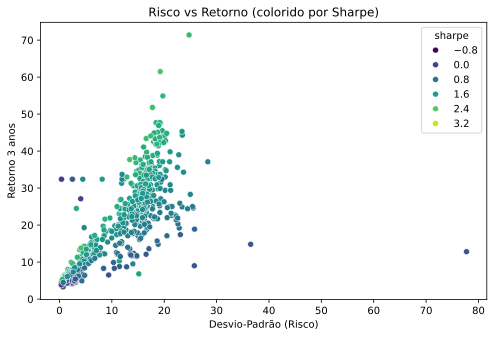

In [124]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['sd'], y=df['returns_3yr'], hue=df['sharpe'], palette='viridis')
plt.title("Risco vs Retorno (colorido por Sharpe)")
plt.xlabel("Desvio-Padrão (Risco)")
plt.ylabel("Retorno 3 anos")
plt.show()

*Insight:*

Observa-se que fundos com retornos elevados nem sempre apresentam Sharpe alto, indicando que parte do retorno pode ser resultado de exposição a risco excessivo — e não de eficiência na gestão.


### 7.2 Insight 2 – Fundos “bons de verdade” (filtro)

In [125]:
df_good = df[
    (df['sharpe'] > df['sharpe'].quantile(0.75)) &
    (df['sd'] < df['sd'].median())
]

df_good[['scheme_name','sharpe','sd','returns_3yr']].head()

,scheme_name,sharpe,sd,returns_3yr
17,Aditya Birla SL Floating Rate Fund,1.66,1.14,6.4
20,Aditya Birla SL FP FoF – Conservative – Direct...,1.57,5.49,13.3
32,Aditya Birla SL Low Duration Fund,2.05,0.97,6.5
36,Aditya Birla SL Money Manager Fund,1.94,0.68,5.6
40,Aditya Birla SL Regular Savings Fund,2.08,4.80,13.9


*Insight:*

Um subconjunto de fundos apresenta simultaneamente alto Sharpe e risco moderado, representando oportunidades mais eficientes para investidores que buscam bom retorno ajustado ao risco.


### 7.3 Insight 3 –  Retorno por unidade de risco

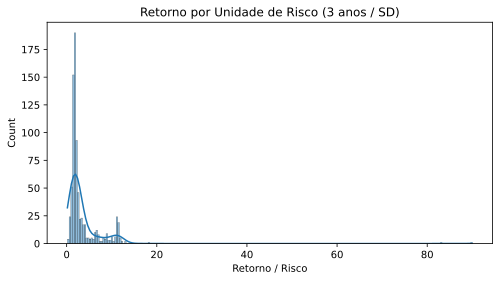

In [126]:
df['risk_return_ratio'] = df['returns_3yr'] / df['sd']

plt.figure(figsize=(8,4))
sns.histplot(df['risk_return_ratio'].dropna(), kde=True)
plt.title("Retorno por Unidade de Risco (3 anos / SD)")
plt.xlabel("Retorno / Risco")
plt.show()

*Insight:*

A distribuição do retorno por unidade de risco mostra forte assimetria, indicando que poucos fundos concentram grande eficiência, enquanto a maioria entrega retorno modesto para o nível de risco assumido.


---


## <a id="conclusoes"></a>8. Conclusões, Limitações e Próximos Passos

### Conclusões

- Fundos eficientes (Sharpe alto) tendem a performar melhor no médio e longo prazo, mas o curto prazo é mais ruidoso.  
- A análise evidencia que retorno absoluto isolado é uma métrica insuficiente, sendo essencial considerar medidas ajustadas ao risco (como Sharpe) para avaliar a real eficiência dos fundos.  
- Categorias de fundos apresentam perfis distintos de risco e retorno, reforçando a importância de segmentar a análise por tipo de produto.  
- Há um grupo pequeno de fundos que combina alto Sharpe com risco moderado, sugerindo oportunidades mais bem calibradas para investidores.

### Limitações

- O dataset contém valores ausentes, especialmente em retornos de 5 anos.  
- Algumas categorias possuem poucos fundos, o que pode distorcer comparações.  
- A análise é puramente exploratória; não há modelagem preditiva ou backtests.

### Próximos Passos

- Criar um ranking de fundos com base em métricas de eficiência (Sharpe, Sortino, retorno por unidade de risco).  
- Aplicar técnicas de clusterização para agrupar fundos com perfis semelhantes.  
- Construir dashboards interativos (ex.: Plotly, Streamlit) para navegação dinâmica pelos resultados.